# 1 - Descarga y exploración del corpus (EDA)

El alumno descargará el/los corpus que desee (detalle sobre los datos a utilizar en
el siguiente punto) y realizará un análisis exploratorio de los datos.
Este ejercicio deberá contener:

- Cardinalidad del vocabulario
- Distribución de reviews por número de estrellas
- No de reviews positivas y negativas
- N-grams más frecuentes
- Nubes de palabras
- Visualización en 2 dimensiones de algunos word embeddings calculados con
Word2Vec (elegir 4-5 palabras y pintar las top 10 más similares)
- Conclusiones de la exploración
- Cualquier otra métrica / exploración / cálculo que el alumno considere

## Datasets
Reviews de Amazon: Reviews de productos de Amazon clasificadas por categorías (libros,
electrónica, automoción, ...). Las reviews contienen la calificación (número de estrellas) por
lo que es perfecto para problemas de clasificación supervisada del sentimiento.
El alumno deberá escoger el dataset que desee (puede trabajar con varios si así lo
prefiere) de los que aparecen en la columna “5-core”. Se recomienda trabajar con
subsets de dichos datasets para evitar problemas de memoria.
Enlace: https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html

El dataset elegido es _Musical Instruments_ con las siguientes características:

    reviewerID - ID of the reviewer, e.g. A2SUAM1J3GNN3B
    asin - ID of the product, e.g. 0000013714
    reviewerName - name of the reviewer
    helpful - helpfulness rating of the review, e.g. 2/3
    reviewText - text of the review
    overall - rating of the product
    summary - summary of the review
    unixReviewTime - time of the review (unix time)
    reviewTime - time of the review (raw)

Link: https://cseweb.ucsd.edu/~jmcauley/datasets/amazon/links.html

Dataset: https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Musical_Instruments_5.json.gz

In [1]:
#Cargamos el dataset
import pandas as pd
import gzip
import urllib.request

df_link = 'https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Musical_Instruments_5.json.gz'
gzFile = 'reviews_Musical_Instruments_5.json.gz'


def download_df(link, toFile):
  urllib.request.urlretrieve(link, toFile)

def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield eval(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')


#--------------------------
download_df(df_link, gzFile)
df = getDF('./' + gzFile )
df.to_csv('df_file.csv')

In [2]:
# función para mostrar texto en negrita
def bold(text):
    return f"\033[1m{text}\033[0m"

In [3]:
df.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      10261 non-null  object 
 1   asin            10261 non-null  object 
 2   reviewerName    10234 non-null  object 
 3   helpful         10261 non-null  object 
 4   reviewText      10261 non-null  object 
 5   overall         10261 non-null  float64
 6   summary         10261 non-null  object 
 7   unixReviewTime  10261 non-null  int64  
 8   reviewTime      10261 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.0+ MB


El dataset no contiene nulos en los campos interesados: reviewText, overall

In [5]:
df.shape

(10261, 9)

In [6]:
#longitud máxima reseña (review)
import numpy as np
import re

rec_max = np.max(df['reviewText'].str.len().argmax())

num_words = 0
list_of_words_rw = []
x_re = ''

for x in df['reviewText'].tolist():
  matches = re.findall('[a-zA-Z0-9 ]*', x)

  len_x = len(matches)

  list_of_words_rw.append(len_x) # list with size of every line
  num_words = max(num_words, len_x) # max num of words per line


# Calculate the median number of words in each line.
median_words_rw = np.median(list_of_words_rw)


corpus = ''
total_words = 0

for x in df['reviewText'].tolist():
  matches = re.findall('[a-zA-Z0-9 ]*', x)
  corpus += ''.join(matches)
  total_words += len(x.split())




In [7]:
print(bold('Max record length          :')+ ' {:>6}'.format(rec_max))
print(bold('Max length words review    :')+ ' {:>6}'.format(num_words))
print(bold('Mean length words review   :')+' {:>6.2f}'.format(median_words_rw))
print(bold('Palabras totales reviewText:'), total_words)


Max record length          :   6576
Max length words review    :    817
Mean length words review   :  17.00
Palabras totales reviewText: 925371


En esta sección obtengo los totales por score (overall) que me servirá para contrastar con el análisis de sentimiento.

In [8]:
ovrall = ovrall = df.groupby('overall')['overall'].count()

print(ovrall.index.values)
print(ovrall.array)

[1. 2. 3. 4. 5.]
<NumpyExtensionArray>
[np.int64(217), np.int64(250), np.int64(772), np.int64(2084), np.int64(6938)]
Length: 5, dtype: int64


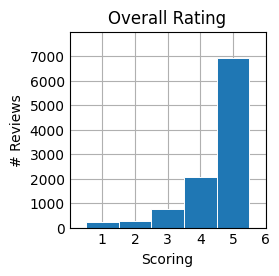

In [9]:
# Distribución de reviews por número de estrellas
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = ovrall.index.values
y = ovrall.array

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(autoscale_on=True,
       xlim=(0,5), xticks=np.arange(1, 7),
       ylim=(0, 8000), yticks=np.arange(0, 8000, 1000))

ax.set_xlabel('Scoring')
ax.set_ylabel('# Reviews')
ax.set_title('Overall Rating')

plt.show()

In [10]:
from collections import Counter

In [11]:
words_nltk = corpus.lower().split()

In [12]:
words_nltk[:10]

['not', 'much', 'to', 'write', 'about', 'here', 'but', 'it', 'does', 'exactly']

In [13]:
wf = Counter(words_nltk)
wf_most_common = wf.most_common(10)
wf_most_common

[('the', 43540),
 ('a', 27752),
 ('and', 26862),
 ('i', 23732),
 ('to', 22967),
 ('it', 19799),
 ('is', 14554),
 ('of', 13579),
 ('for', 12984),
 ('this', 11223)]

In [14]:
# N-gramas
from nltk import ngrams
from nltk.probability import FreqDist

In [15]:
bigrams_ = list(ngrams(words_nltk, 2))
trigrams_ = list(ngrams(words_nltk, 3))

In [16]:
bigrams_[:10]

[('not', 'much'),
 ('much', 'to'),
 ('to', 'write'),
 ('write', 'about'),
 ('about', 'here'),
 ('here', 'but'),
 ('but', 'it'),
 ('it', 'does'),
 ('does', 'exactly'),
 ('exactly', 'what')]

In [17]:
trigrams_[:10]

[('not', 'much', 'to'),
 ('much', 'to', 'write'),
 ('to', 'write', 'about'),
 ('write', 'about', 'here'),
 ('about', 'here', 'but'),
 ('here', 'but', 'it'),
 ('but', 'it', 'does'),
 ('it', 'does', 'exactly'),
 ('does', 'exactly', 'what'),
 ('exactly', 'what', 'its')]

In [18]:
# Wordcloud
from wordcloud import WordCloud
def plot_word_cloud(corpus):
    wordcloud = WordCloud(max_font_size=50, max_words=50, background_color="white").generate(' '.join(corpus))
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

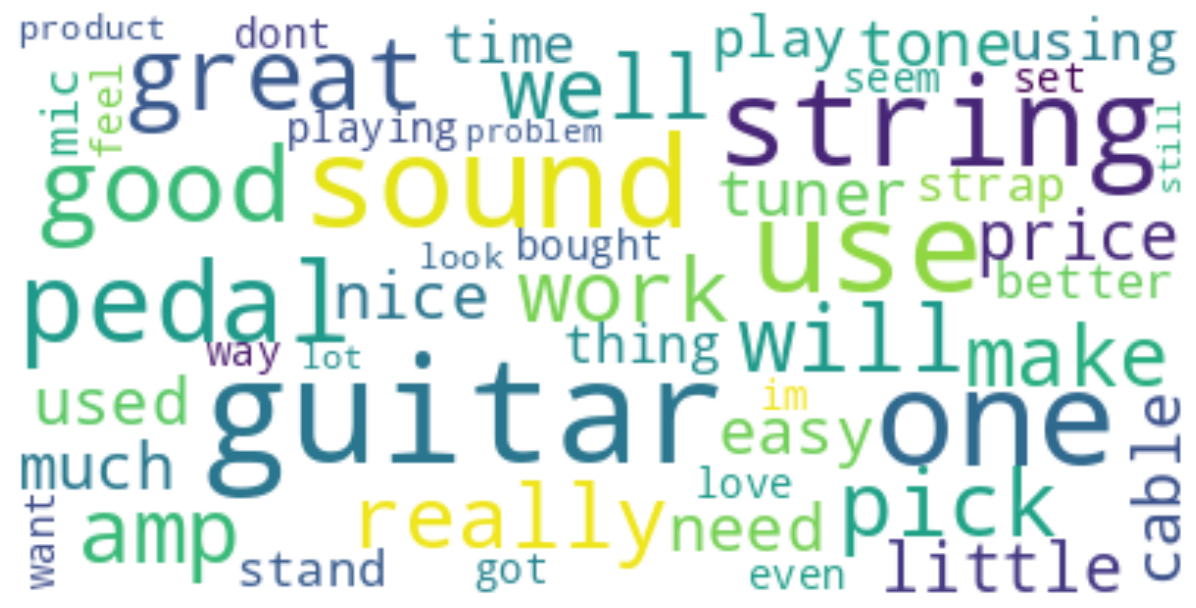

In [19]:
words_list = corpus.lower().strip().split()
plot_word_cloud(words_list)

# 2 - Preprocesamiento

In [20]:
# Dependencias
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re
import numpy as np
import random
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# NLP Preprocessing pipeline
class nlp_pipeline:
  '''
  nlp_pipeline realiza el preprocesado del corpus
  antes del entrenamiento.
  Parámetros:
  -----------
  -> Array de strings
  <- Array de string preprocesados

  Tratamiento:
  ------------
  - minúsculas
  - eliminar caracteres
  - tokenizar
  - quitar stop words
  - pad sequence (tamaño medio reviews)
  '''
  def __init__(self, corpus):
    self.corpus = corpus
    self.stop_words_list = set(stopwords.words('english'))

  def preprocessing(self):
      prep_corpus = self.corpus.copy()
      for pos, line in enumerate(prep_corpus):
        line = self.to_lower(line)
        line = self.leave_nonword_chars(line)
        prep_corpus[pos] = self.leave_stop_words(line)

      return np.array(self.pad_sequence(prep_corpus))

  def to_lower(self, param:str):
    '''
    Get a parameter string
    Return the same content but in lowercase
    '''

    return param.lower()

  def leave_nonword_chars(self, param:str):
    '''
    Get a parameter string
    Return the non alphanumeric characters
    '''
    return re.sub('[^a-zA-Z0-9 ]', '', param)

  def leave_stop_words(self, param:str):
    '''
    Get a parameter string
    Return the non stopword words
    '''
    return " ".join([word for word in param.split() if word not in self.stop_words_list])

  def pad_sequence(self, param: list):
    '''
    Get a parameter list
    Return a new list with pad sequence as a result
    of the mean length of the list text lines
    '''

    # Give a list with the size of each line
    list_of_words = [len(line.split())  for line in param]

    # Calculate the median number of words in the list of lines
    median_words = np.median(list_of_words)

    int_median_words = int(np.round(median_words, 0))

    # Truncate all the lines to the median length of words
    trunc_list = []
    for line in param:
      temp_low=line.split() #temp list of words by line

      trunc_list.append(" ".join(temp_low[:int_median_words]))

    # Returns truncated list with the default pad_sequence
    return trunc_list



In [22]:
#pd.set_option('display.max_colwidth', None)
df[['reviewText', 'overall']][:5]

,reviewText,overall
0,"Not much to write about here, but it does exac...",5.0
1,The product does exactly as it should and is q...,5.0
2,The primary job of this device is to block the...,5.0
3,Nice windscreen protects my MXL mic and preven...,5.0
4,This pop filter is great. It looks and perform...,5.0


In [23]:
# Añadimos una columna para la clasificación binaria
'''
Criterio binario para análisis de sentimiento
Overall: 0-5
Distribución:
Overall     Sentimiento (1-positivo, 0-negativo)
-------     -----------
0-3           0
4-5           1
'''

df['bin_label'] = df.apply(lambda row: 1 if row['overall'] >= 4 else 0, axis=1)

In [24]:
nlp_pipe_inst = nlp_pipeline(df['reviewText'])
preproc_corpus = nlp_pipe_inst.preprocessing()
preproc_corpus[:5]

array(['much write exactly supposed filters pop sounds recordings much crisp one lowest prices pop filters amazon might well buy honestly work despite pricing',
       'product exactly quite affordablei realized double screened arrived even better expectedas added bonus one screens carries small hint smell old grape candy used buy reminiscents sake cannot',
       'primary job device block breath would otherwise produce popping sound allowing voice pass noticeable reduction volume high frequencies double cloth filter blocks pops lets voice coloration metal',
       'nice windscreen protects mxl mic prevents pops thing gooseneck marginally able hold screen position requires careful positioning clamp avoid sagging',
       'pop filter great looks performs like studio filter youre recording vocals eliminate pops gets recorded sing'],
      dtype='<U372')

In [25]:
# BoW - CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='word', ngram_range=(1, 1))
X2 = vectorizer.fit_transform(preproc_corpus)
X2.sum(axis=0)
total_counts = X2.sum(axis=0).tolist()[0]
words = vectorizer.get_feature_names_out()

In [26]:
# Number of times a word appears
word_counts = dict(zip(words, total_counts))
print(word_counts)

{'000': 2, '0012053': 1, '0022uf': 2, '0028': 1, '009': 3, '009042': 1, '01': 1, '010': 4, '010s': 1, '011': 5, '012': 2, '012dlx': 1, '012s': 2, '013': 2, '0135013': 1, '013s': 1, '016': 1, '016ny': 2, '02': 1, '025026': 1, '028': 1, '0313': 1, '032': 1, '034036': 1, '038': 1, '042': 1, '046mm': 1, '048': 1, '05': 4, '053': 1, '05mm': 1, '060mm': 3, '07': 4, '0733150406': 1, '08': 2, '0818': 1, '088mm': 1, '09': 2, '0942': 1, '099': 1, '0990502000': 1, '09s': 1, '0db': 1, '10': 153, '100': 95, '1000': 7, '1000500': 1, '1000s': 1, '100low': 1, '100mm': 2, '100pound': 1, '100s': 2, '100th': 1, '100w': 2, '100watt': 1, '101': 1, '1012': 1, '1015': 2, '1020': 1, '103': 1, '1032': 1, '1046': 5, '1046s': 1, '1047s': 1, '1052': 1, '1099': 1, '10a125': 1, '10db': 1, '10feet': 1, '10foot': 2, '10footers': 1, '10ft': 2, '10i': 1, '10k': 1, '10lol': 1, '10m': 1, '10mm': 3, '10pack': 1, '10s': 18, '10th': 1, '10w': 1, '10watts': 1, '10x': 2, '10xs': 1, '11': 18, '110': 3, '1100': 1, '110v': 1, '1

## Features

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# creo mi columna de referencia
ground_truth = df['bin_label']


In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    preproc_corpus,
    ground_truth,
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    shuffle=True,
    stratify=ground_truth
)

In [30]:
# Extracción características TF-IDF
tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=2500,
    strip_accents='ascii',
    ngram_range=(1, 1)
)
tfidf.fit(x_train)

TfidfVectorizer(max_df=0.95, max_features=2500, min_df=5, strip_accents='ascii')

In [31]:
print(list(tfidf.vocabulary_.items())[:20])

[('good', np.int64(904)), ('dont', np.int64(615)), ('see', np.int64(1864)), ('better', np.int64(232)), ('basic', np.int64(201)), ('strings', np.int64(2096)), ('price', np.int64(1646)), ('range', np.int64(1711)), ('work', np.int64(2456)), ('well', np.int64(2416)), ('length', np.int64(1172)), ('somewhat', np.int64(2003)), ('appears', np.int64(142)), ('level', np.int64(1180)), ('hosa', np.int64(1016)), ('cable', np.int64(307)), ('quality', np.int64(1700)), ('place', np.int64(1571)), ('products', np.int64(1663)), ('sound', np.int64(2014))]


In [32]:
x_train_ = tfidf.transform(x_train)
x_test_ = tfidf.transform(x_test)

In [33]:
# Some review words (TF-IDF)
i = random.randint(0, len(x_train))


doc_vector = x_train_[i]
df_tfidf = pd.DataFrame(doc_vector.T.todense(), index=tfidf.get_feature_names_out(), columns=['tfidf'])
df_tfidf = df_tfidf[df_tfidf['tfidf'] > 0]

top_n = 10


In [34]:
print(bold('ID        :')+' {}'.format(i))
print(bold('Sentiment :')+' {}'.format(y_train.iloc[i]))
print(bold('Review    :')+' {} \n'.format(x_train[i]))

print('Top {} words with highest TF_IDF in the review {}:\n{}'.format(top_n, i, df_tfidf.sort_values(by=["tfidf"],ascending=False)[:top_n]))
print('\nTop {} words with lowest TF_IDF in the review {}:\n{}'.format(top_n, i, df_tfidf.sort_values(by=["tfidf"],ascending=False)[-top_n:]))

ID        : 4557
Sentiment : 1
Review    : seems great need time explore 

Top 10 words with highest TF_IDF in the review 4557:
          tfidf
seems  0.603627
need   0.520022
time   0.497650
great  0.342863

Top 10 words with lowest TF_IDF in the review 4557:
          tfidf
seems  0.603627
need   0.520022
time   0.497650
great  0.342863


# 3 - Modelo GRU

## Dependencias

In [35]:
import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec
try:
  import mlflow
except:
  !pip install mlflow==3.13.0
  import mlflow
import time

In [36]:
cores = multiprocessing.cpu_count() # Contamos el número de cores en el ordenador
print ('Available cores:', cores)

Available cores: 2


## Embedding

En esta parte creamos el embedding que nos da la relación semántica entre las palabras del corpus.

In [37]:
# We're creating embeddings for GRU model
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=cores-1)

In [38]:
t_start = time.time()
sent = [row.split() for row in x_train]
w2v_model.build_vocab(sent, progress_per=10000)
t_end = time.time()

In [39]:
print('Time to build the vocabulary: {} mins'.format(round((t_end - t_start) / 60, 2)))
print('The vocabulary is composed by {} words'.format(len(w2v_model.wv.key_to_index)))

Time to build the vocabulary: 0.0 mins
The vocabulary is composed by 1277 words


In [40]:
# Training word2vec model
t_start = time.time()

w2v_model.train(sent, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

t_end = time.time()


In [41]:

print('Time to train the model: {} mins'.format(round((t_end - t_start) / 60, 2)))

Time to train the model: 0.17 mins


In [42]:
# Nos quedamos con las 100 palabras más utilizadas
top_words = list(w2v_model.wv.key_to_index.keys())[:100]

# Extraemos los vectores
vectors = np.array([w2v_model.wv[word] for word in top_words])

In [43]:
from sklearn.decomposition import PCA

# PCA - Reducimos dimensiones
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

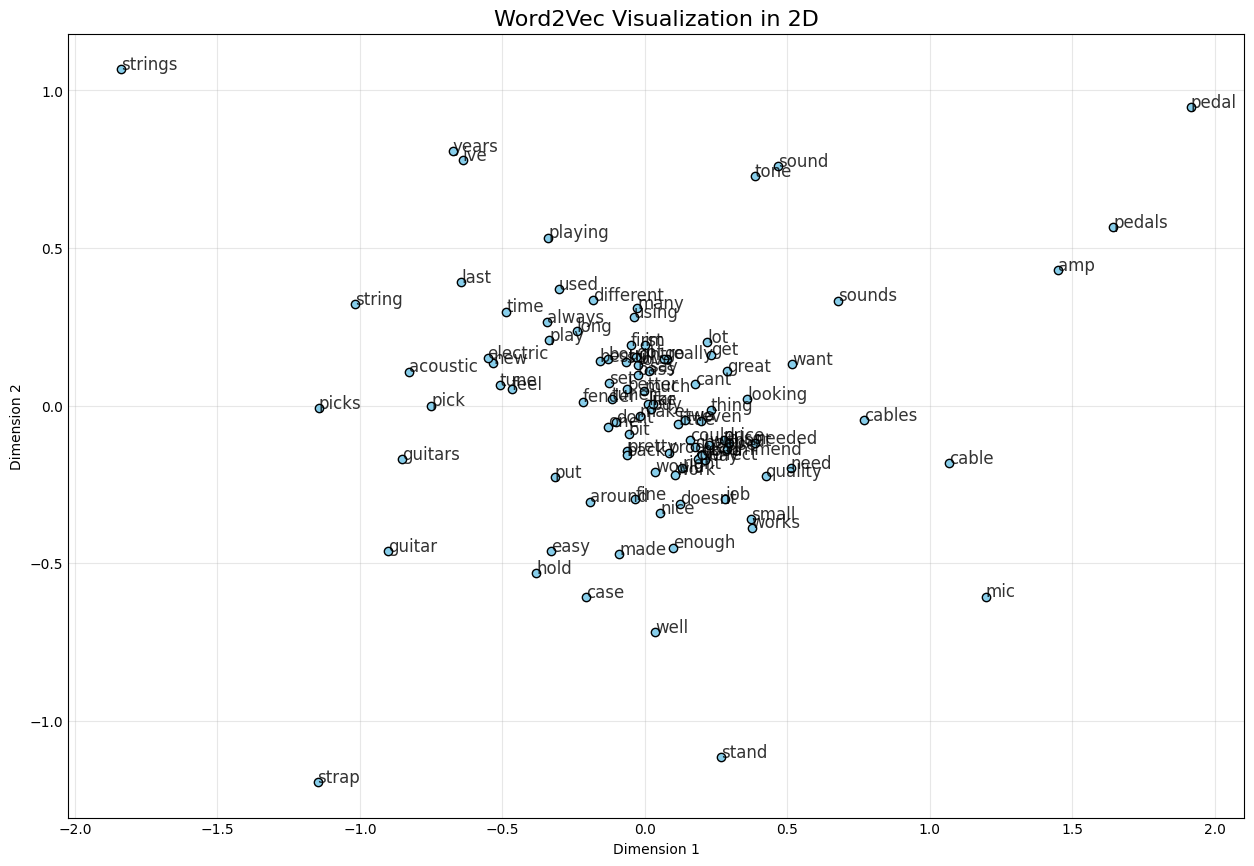

In [44]:
# Dibujamos el gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Scatter plot
x = reduced_vectors[:, 0]
y = reduced_vectors[:, 1]

plt.scatter(x, y, color='skyblue', edgecolors='black')

# Add labels to each point
for i, word in enumerate(top_words):
    plt.annotate(word, (x[i], y[i]), fontsize=12, alpha=0.8)

plt.title('Word2Vec Visualization in 2D', fontsize=16)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

### Información del word2vec generado

In [45]:
w2v_model.wv.most_similar(positive=["guitar"])

[('guitars', 0.987044632434845),
 ('neck', 0.9796016216278076),
 ('locks', 0.975145161151886),
 ('straps', 0.9686566591262817),
 ('lock', 0.9598761200904846),
 ('uke', 0.9590210318565369),
 ('nylon', 0.9588447213172913),
 ('locking', 0.9586886167526245),
 ('hold', 0.956464409828186),
 ('acoustic', 0.956436038017273)]

In [46]:
w2v_model.wv.most_similar(positive=["string"])


[('acoustic', 0.9754698276519775),
 ('elixir', 0.9698543548583984),
 ('wound', 0.9670790433883667),
 ('bronze', 0.9635582566261292),
 ('coated', 0.9631199836730957),
 ('martin', 0.962031364440918),
 ('daddario', 0.9616798162460327),
 ('steel', 0.9593961834907532),
 ('last', 0.9581807255744934),
 ('longer', 0.958154559135437)]

In [47]:
w2v_model.wv.most_similar(positive=["drum"])

[('portable', 0.9954089522361755),
 ('drums', 0.9950161576271057),
 ('equipment', 0.993976891040802),
 ('stage', 0.9937447905540466),
 ('function', 0.9934114813804626),
 ('need', 0.9933651685714722),
 ('able', 0.9931591153144836),
 ('desktop', 0.9928667545318604),
 ('mike', 0.9924976229667664),
 ('device', 0.9920425415039062)]

In [48]:
w2v_model.wv.similarity('guitar', 'string')

np.float32(0.90897965)

In [49]:
w2v_model.wv.similarity('microphone', 'banjo')

np.float32(0.7942375)

In [50]:
w2v_model.wv.doesnt_match(['strings', 'guitar', 'device'])

'strings'

In [51]:
w2v_model.wv.vectors

array([[-0.09268105,  0.09548959,  0.01112183, ..., -0.11176256,
         0.02646852,  0.17833765],
       [-0.18476938,  0.07363865, -0.06206161, ..., -0.09474501,
         0.04715651,  0.13696492],
       [-0.09311258,  0.08871922, -0.04850857, ..., -0.06629765,
         0.05099511,  0.0928389 ],
       ...,
       [-0.17680179,  0.07628514, -0.06107659, ..., -0.07584647,
         0.05030879,  0.10233977],
       [-0.17191096,  0.08786197, -0.05125877, ..., -0.08637946,
         0.04450213,  0.1323358 ],
       [-0.1527446 ,  0.07076406, -0.05378653, ..., -0.08316445,
         0.02411805,  0.13048066]], dtype=float32)

## Tokenizing & Padding train data

La tokenización se encarga de pasar cada palabra a número para que pueda ser tratada por el modelo.

El padding se ocupa de dejar todos los registros de la misma longitud para que el modelo lo trate de forma eficiente.

In [52]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = int(median_words_rw)  # sequence length


# Initialize tokenizer
tokenizr = Tokenizer(oov_token="<OOV>")
tokenizr.fit_on_texts(x_train)

vocab_size =  len(tokenizr.word_index) + 1  # vocabulary size

# texte to sequence
seq = tokenizr.texts_to_sequences(x_train)
x_train_gru = pad_sequences(seq, padding='post', truncating='post', maxlen=max_words)

seq_test = tokenizr.texts_to_sequences(x_test)
x_test_gru = pad_sequences(seq_test, padding='post', truncating='post', maxlen=max_words)


In [53]:
print(bold('Raw             :'), x_train[100:])
print(bold('Vocabulary size :'), vocab_size)
print(bold('Sequences       :'), seq)
print(bold('Pad sequences   :'), x_train_gru)
print(bold('Word index      :'), tokenizr.word_index)


Raw             : ['elixir strings nice slick last forever compared standard stringsbut admit addario strings good replaced often money want try technology advanced strings dont think disappointed people say slick'
 'harmonica barely fits holder adjustment distance mouth harmonica cant get harmonica adjusted close enough play unless modify'
 'unfortunately wasnt aware slides come sizes got medium need large medium fits pinky finger thats okay prefered fit index finger id controli cannot fault slide foolish choice'
 ...
 'simple humidifier guitars round sound hole would work fhole archtop types instruments mandolin ukulele inside sturdy plastic case appears ordinary kitchen sponge use distilled water recommended last'
 'les paul heavy strap would constantly fall decided get set strap locks installed minutes really dont change look guitar need nut driver screw lock strap dont locks'
 'guitar stand built good buy cost would purchase']
Vocabulary size : 15198
Sequences       : [[5, 23, 118

In [54]:
# Obtenemos la dimensión del Word2Vec
embedding_dim = w2v_model.vector_size  # 300

# creamos matriz vacía
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Llenamos la matriz
for word, i in tokenizr.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

## Definición del modelo

In [55]:
from keras.models import Sequential
from keras.layers import Embedding,  Dense, Dropout, GRU

embedding_size = 32
gru_model = Sequential()
gru_model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_words))
gru_model.add(GRU(64))
gru_model.add(Dense(1, activation='sigmoid'))

print(gru_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,559,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,559,400 (17.39 MB)

 Trainable params: 4,559,400 (17.39 MB)

 Non-trainable params: 0 (0.00 B)

None


In [56]:
gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## Split de datos (train y test)

In [57]:
# Split de las secuencias rellenadas
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    x_train_gru,
    y_train, # columna con valores numéricos: 0 y 1
    test_size=0.2,
    random_state=42
)

## Entrenamiento del modelo

In [58]:
# Train feat Claude
batch_size = [32, 64, 128]
gru_units_options = [32, 64]
optimizers = ['adam', 'rmsprop']
num_epochs = 1

SERVER = "https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/"
mlflow_server = SERVER
mlflow.set_tracking_uri(mlflow_server) #Usa servidor local
mlflow.set_experiment('practica-model-ia5')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for bs in batch_size:
  for units in gru_units_options:
    for opt in optimizers:

      run_name = f'GRU-bs{bs}-u{units}-{opt}'

      # Construimos un modelo nuevo en cada combinacion para que no herede
      # pesos ya entrenados con otra configuracion (si no, la comparacion
      # entre runs no seria justa)
      gru_model = Sequential()
      gru_model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_words))
      gru_model.add(GRU(units))
      gru_model.add(Dense(1, activation='sigmoid'))
      gru_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

      gru_model.fit(X_train2,
                    y_train2,
                    #validation_data=(X_test2, y_test2),
                    batch_size=bs,
                    epochs=num_epochs,
                    verbose=0)

      scores_train = gru_model.evaluate(X_train2, y_train2, verbose=0)
      scores_test = gru_model.evaluate(X_test2, y_test2, verbose=0)

      # Metricas adicionales (accuracy, precision, recall, f1) sobre test
      y_pred_raw = gru_model.predict(X_test2, verbose=0)
      y_pred = np.nan_to_num(y_pred_raw, nan=0.0)
      y_pred = (y_pred > 0.5).astype(int).flatten()

      acc = accuracy_score(y_test2, y_pred)
      prec = precision_score(y_test2, y_pred, average='weighted', zero_division=0)
      rec = recall_score(y_test2, y_pred, average='weighted', zero_division=0)
      f1 = f1_score(y_test2, y_pred, average='weighted', zero_division=0)

      with mlflow.start_run(run_name=run_name):
          # Parametros (lo que configuramos nosotros)
          mlflow.log_param('batch_size', bs)
          mlflow.log_param('gru_units', units)
          mlflow.log_param('optimizer', opt)

          # Metricas de Keras durante el entrenamiento
          mlflow.log_metric('loss_train', scores_train[0])
          mlflow.log_metric('accuracy_train_keras', scores_train[1])
          mlflow.log_metric('loss_test', scores_test[0])
          mlflow.log_metric('accuracy_test_keras', scores_test[1])

          # Metricas de sklearn (las que usamos para comparar modelos)
          mlflow.log_metric('accuracy_score', acc)
          mlflow.log_metric('precision_score', prec)
          mlflow.log_metric('recall_score', rec)
          mlflow.log_metric('f1_score', f1)

          mlflow.keras.log_model(gru_model, artifact_path='gru')

      resultados.append({
          'modelo': run_name,
          'accuracy': acc,
          'precision': prec,
          'recall': rec,
          'f1': f1
      })

      print(f"{run_name}: accuracy={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  f1={f1:.3f}")


2026/06/26 20:45:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 20:46:01 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run GRU-bs32-u32-adam at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/6370d67ff939494496c66dac2bc3116c
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
GRU-bs32-u32-adam: accuracy=0.870  precision=0.757  recall=0.870  f1=0.810


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026/06/26 20:47:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 20:47:05 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run GRU-bs32-u32-rmsprop at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/6c6cc657f1294fc7bdc57ad038a91050
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
GRU-bs32-u32-rmsprop: accuracy=0.870  precision=0.757  recall=0.870  f1=0.810


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026/06/26 20:47:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 20:47:58 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

🏃 View run GRU-bs128-u32-rmsprop at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/d05aa40f1b5f45bca3b61e715b6143ab
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
GRU-bs128-u32-rmsprop: accuracy=0.870  precision=0.757  recall=0.870  f1=0.810


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026/06/26 20:54:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 20:54:53 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run GRU-bs128-u64-adam at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/2879ff1f36974dfcab8d09ef252c8859
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
GRU-bs128-u64-adam: accuracy=0.870  precision=0.757  recall=0.870  f1=0.810


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026/06/26 20:55:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/26 20:55:48 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run GRU-bs128-u64-rmsprop at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/0a46efd3a14f455b933b355ac96e7155
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
GRU-bs128-u64-rmsprop: accuracy=0.870  precision=0.757  recall=0.870  f1=0.810


In [59]:
import os

In [60]:
# guardamos el modelo en el colab
cache_dir='./'
model_file = "gru_model.h5"  # HDF5 file
gru_model.save(os.path.join(cache_dir, model_file))

In [61]:
# Obtenemos accuracy
scores = gru_model.evaluate(X_test2, y_test2, verbose=0)  # returns loss and other metrics specified in model.compile()
gru_accuracy = scores[1]*100
print("Test accuracy: {:>6.2f}%".format(gru_accuracy, 2))  # scores[1] should correspond to accuracy if you passed in metrics=['accuracy']

Test accuracy:  87.00%


## Métricas y conclusiones (GRU)

In [62]:
y_pred_gru_raw = gru_model.predict(X_test2)
y_pred_gru = (y_pred_gru_raw > 0.5).astype(int).flatten()

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [63]:
def metricas_gru(y_pred_gru_local):
  # Initializing array of integers
  y_pred_gru_int = np.empty_like(y_pred_gru_local)

  for i in range(len(y_pred_gru_local)):
    if np.isnan(y_pred_gru_local[i][0]):
      y_pred_gru_int[i][0] = 0
    try:
      y_pred_gru_int[i] = int(np.round(y_pred_gru_local[i][0]))
    except:
      y_pred_gru_int[i] = 0


  # Printing predictions

  length_gru = len(y_pred_gru_int)
  count_0_gru = 0
  count_1_gru = 0
  for j in range(len(y_pred_gru_int)):
    if y_pred_gru_int[j] == 0:
      count_0_gru += 1
    else:
      count_1_gru += 1
  return count_0_gru, count_1_gru, length_gru, y_pred_gru_int

def mostrar_metricas_gru(y_pred_gru_local, y_test_local):
  count_0_gru, count_1_gru, length_gru, y_pred_gru_final = metricas_gru(y_pred_gru_local)
  with mlflow.start_run(run_name='GRU-with-model-weigths'):
      mlflow.log_param('count_negative', count_0_gru)
      mlflow.log_param('count_positive', count_1_gru)

  print(bold('Prediction gru'))
  print('  gru accuracy: {:>4.2f}'.format(gru_accuracy))
  print('  0 gru : {:>4}'.format(count_0_gru), '({:>6.2f}%)'.format(count_0_gru/length_gru * 100))
  print('  1 gru : {:>4}'.format(count_1_gru), '({:>6.2f}%)'.format(count_1_gru/length_gru * 100))
  print('\n')
  return y_pred_gru_final

In [64]:
y_pred_gru_final = mostrar_metricas_gru(y_pred_gru_raw, y_test2)

🏃 View run GRU-with-model-weigths at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1/runs/9d056bda5ade441fb01b41730b1e6df0
🧪 View experiment at: https://ff21-2a02-9130-fd1e-9ac-ca2-ed5c-aaed-3164.ngrok-free.app/#/experiments/1
Prediction gru
  gru accuracy: 87.00
  0 gru :    0 (  0.00%)
  1 gru : 1539 (100.00%)




In [65]:
# metricas2 feat. Deepseek + Gemini
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def metricas2(y_true, y_pred, nombre):
    """Calcula las 4 métricas principales"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Nota: las metricas de cada configuracion (batch_size, gru_units, optimizer)
    # ya se registran en MLflow dentro del bucle de entrenamiento de arriba.
    # Esta funcion se deja solo para inspeccionar un modelo concreto sin volver
    # a tocar mlflow ni la lista `resultados` (que ya contiene el grid completo).

    print(f"\n{nombre}")

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Matriz de confusión simple
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nMatriz de Confusión:")
    print(f"              Predicho 0  Predicho 1")
    print(f"Real 0        {cm[0,0]:6d}       {cm[0,1]:6d}")
    print(f"Real 1        {cm[1,0]:6d}       {cm[1,1]:6d}")

    return {'modelo': nombre, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

#---------------------------------------#
####            Métricas 2           ####
#---------------------------------------#
# - Accuracy
# - Precision
# - Recall
# - F1

# Inspeccion rapida del ultimo modelo entrenado en el bucle (no se añade a
# `resultados`, que ya tiene las 12 combinaciones del grid search)
_ = metricas2(y_test2, y_pred_gru, "GRU (ultima config. del grid)")


GRU (ultima config. del grid)
Accuracy:  0.8700
Precision: 0.7570
Recall:    0.8700
F1-Score:  0.8096

Matriz de Confusión:
              Predicho 0  Predicho 1
Real 0             0          200
Real 1             0         1339


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


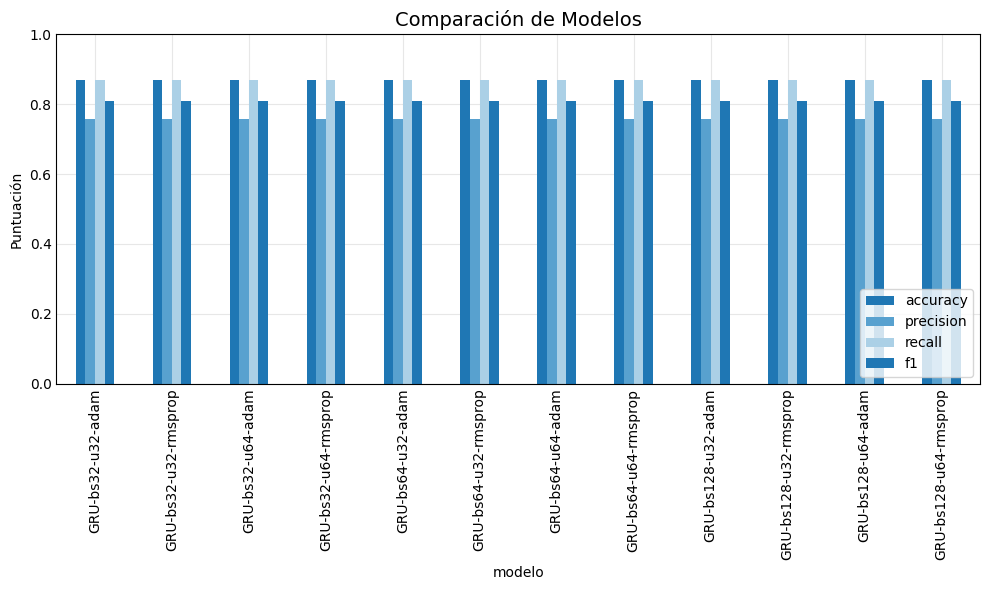

In [66]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.set_index('modelo')
df_resultados[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(10,6))

plt.title('Comparación de Modelos', fontsize=14)
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

4 - MLFLOW

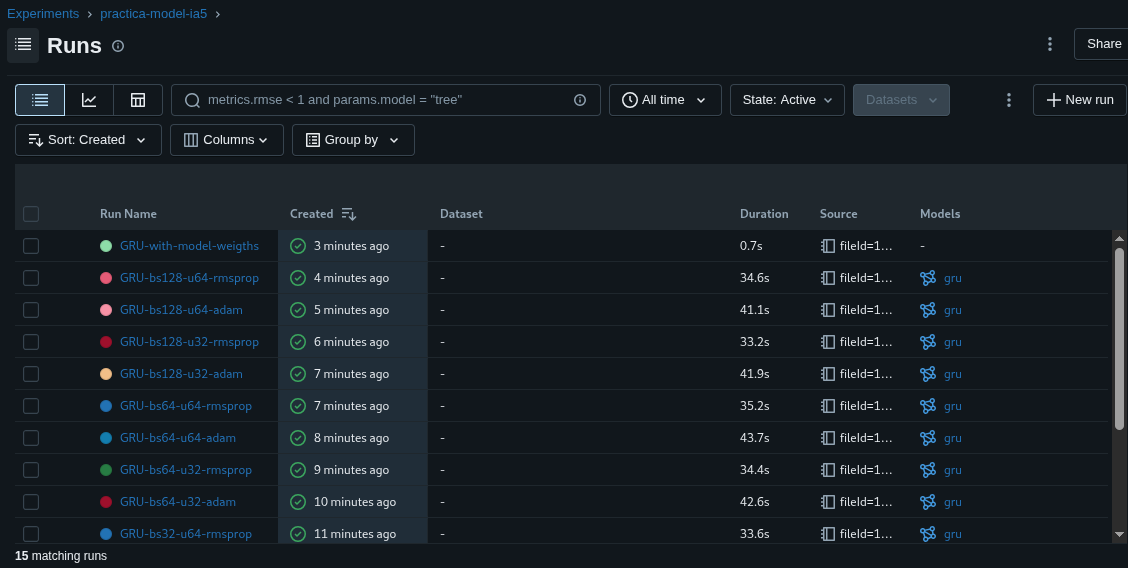

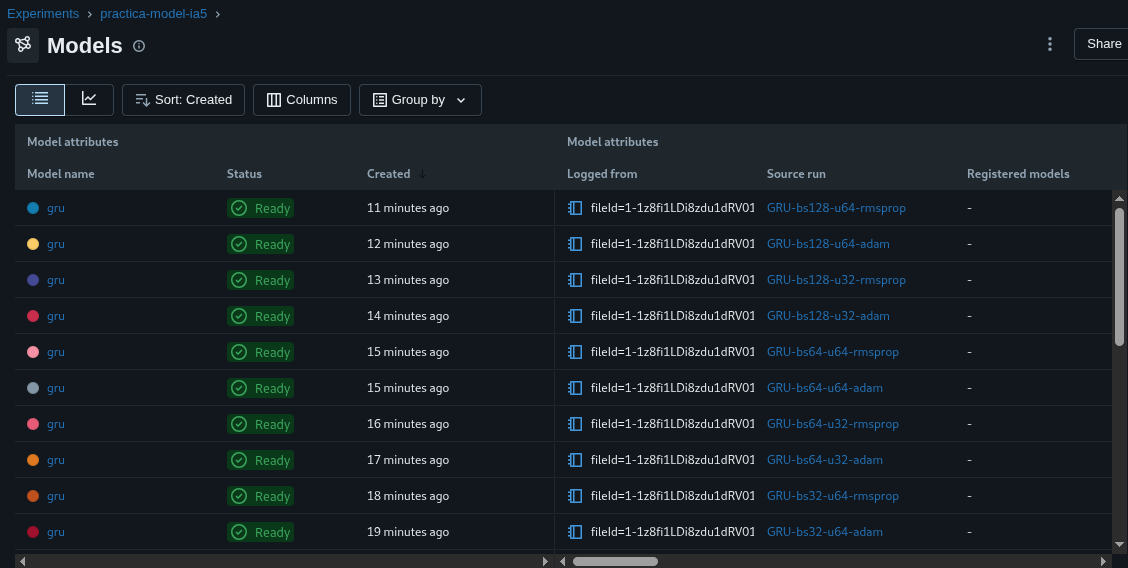

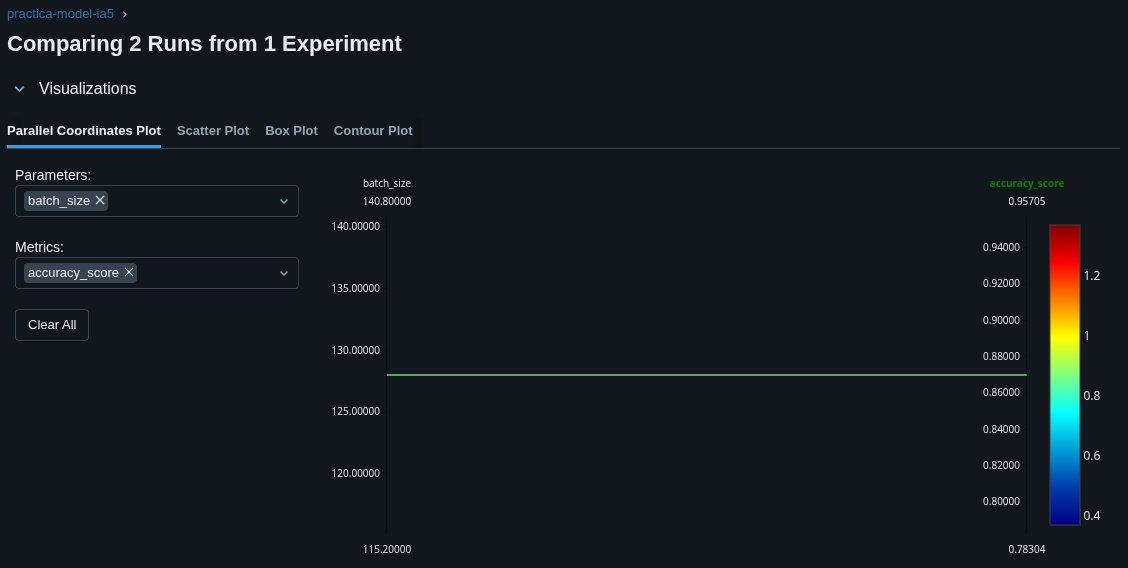

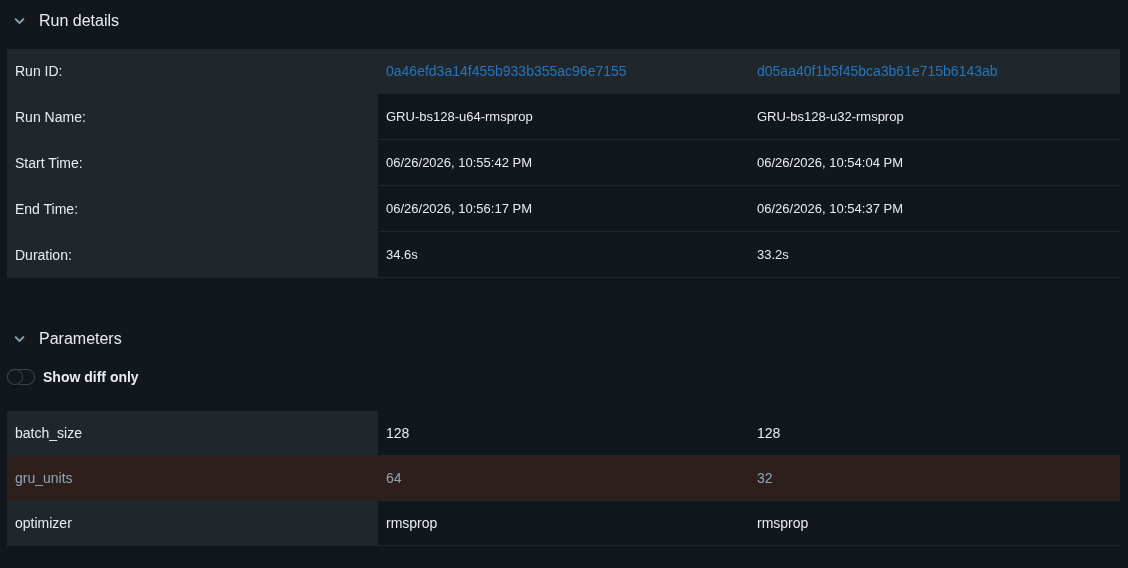

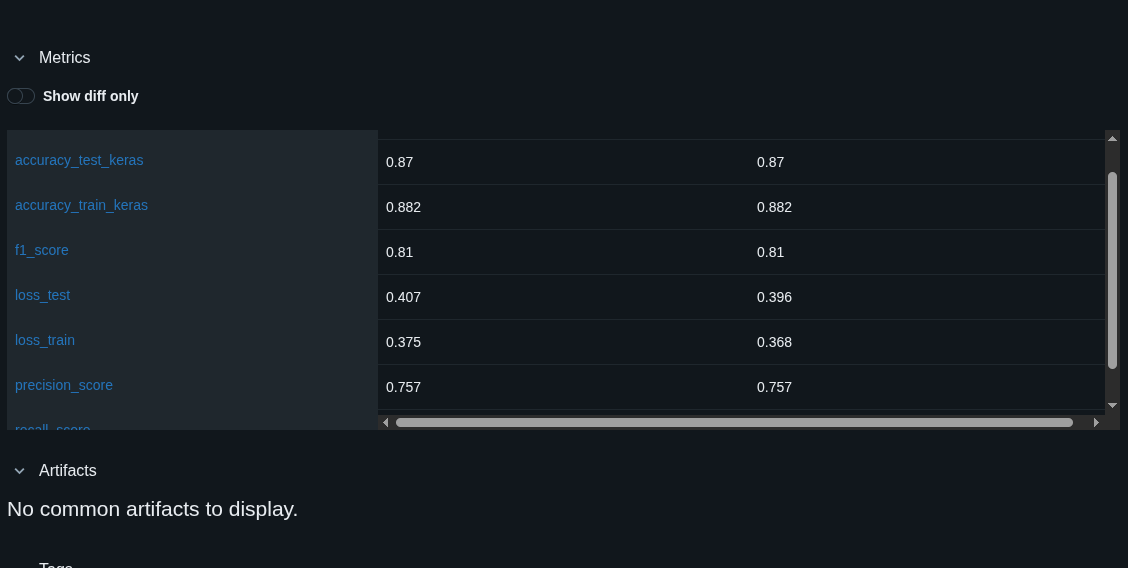